# 1. Setup

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import hdbscan

scaled = pd.read_csv("../data/processed/wallet_features_scaled.csv")
raw = pd.read_csv("../data/processed/wallet_features.csv")
FEATURE_COLS = [c for c in scaled.columns if c != "wallet"]

X = scaled[FEATURE_COLS].values
print(f"Shape: {X.shape}")

Shape: (31527, 12)


## 2. K-Means: Hyperparameters (Elbow + Silhouette Sweep)

k= 2  inertia=    268234  silhouette=0.383
k= 3  inertia=    229737  silhouette=0.402
k= 4  inertia=    207419  silhouette=0.278
k= 5  inertia=    187529  silhouette=0.286
k= 6  inertia=    170829  silhouette=0.296
k= 7  inertia=    155632  silhouette=0.304
k= 8  inertia=    142721  silhouette=0.317
k= 9  inertia=    136159  silhouette=0.325
k=10  inertia=    130239  silhouette=0.324


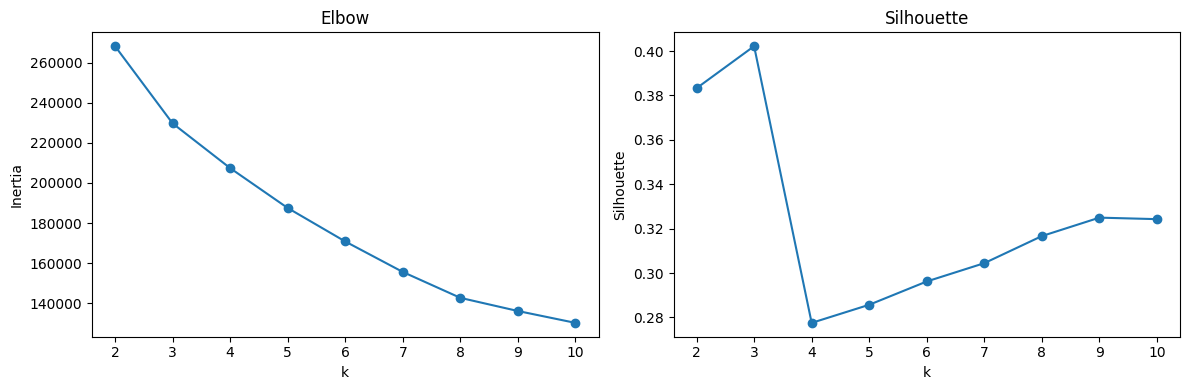

In [69]:
ks = list(range(2, 11))
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    # silhouette is expensive on 30k rows — sample
    sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:>10.0f}  silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, "o-"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow")
axes[1].plot(ks, silhouettes, "o-"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette")
plt.tight_layout(); plt.show()

## 3. K-Means: Fit Final Model

In [ ]:
K = 5  # Picked based on plot from cell 2

km = KMeans(n_clusters=K, n_init=10, random_state=42)
km_labels = km.fit_predict(X)

# attach to raw (unscaled) features for interpretation
results = raw.copy()
results["km_cluster"] = km_labels

print(f"K-Means cluster sizes:")
print(results["km_cluster"].value_counts().sort_index())

profile = results.groupby("km_cluster")[FEATURE_COLS].mean().round(2)
profile["size"] = results["km_cluster"].value_counts().sort_index()
profile = profile[["size"] + FEATURE_COLS]
print(profile.to_string())

K-Means cluster sizes:
km_cluster
0     9599
1      696
2     5782
3    15450
Name: count, dtype: int64
             size  tx_count  total_value_eth_sent  total_value_eth_received    avg_gas  unique_recipients  unique_senders  contract_call_ratio  tx_frequency  tokens_sent_count  tokens_received_count  unique_tokens_sent  unique_tokens_received
km_cluster                                                                                                                                                                                                                                        
0            9599      0.02                  0.00                      0.19     435.45               0.02            6.67                 0.00          0.02              17.06                  17.42                2.36                    2.18
1             696     53.19                395.02                    326.30  157846.45              24.50           45.68                 0.46         53.19           

# 4. DBSCAN

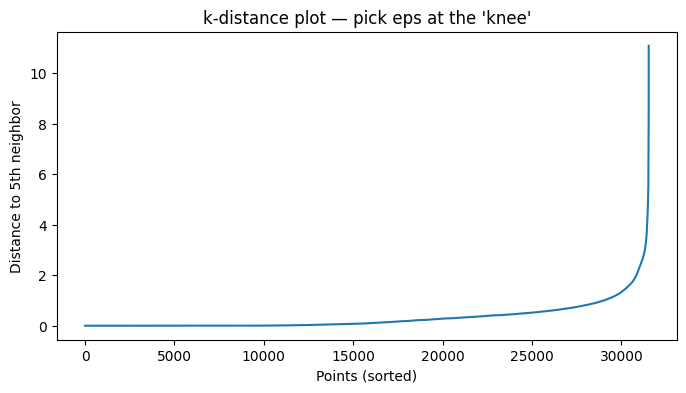

In [95]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5).fit(X)
dists, _ = nn.kneighbors(X)
k_dist = np.sort(dists[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel("Points (sorted)"); plt.ylabel("Distance to 5th neighbor")
plt.title("k-distance plot — pick eps at the 'knee'")
plt.show()

In [96]:
# Tuning
for eps in [0.5, 0.7, 1.0, 1.3, 1.7]:
    db = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    largest = pd.Series(labels[labels != -1]).value_counts().max() if (labels != -1).any() else 0
    print(f"eps={eps:.1f}  clusters={n_clusters:3d}  noise={noise_pct:5.1f}%  largest={largest:,}")

eps=0.5  clusters=141  noise= 22.9%  largest=1,676
eps=0.7  clusters= 39  noise= 13.7%  largest=5,264
eps=1.0  clusters= 14  noise=  7.4%  largest=13,611
eps=1.3  clusters=  9  noise=  4.8%  largest=14,108
eps=1.7  clusters=  4  noise=  2.9%  largest=21,299


In [104]:
EPS = 1.0

db = DBSCAN(eps=EPS, min_samples=20)
db_labels = db.fit_predict(X)
results["db_cluster"] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise:,} noise points ({n_noise/len(X):.1%})")
print(f"Cluster sizes:\n{pd.Series(db_labels).value_counts().sort_index()}")
print(f"DBSCAN noise: {(db_labels == -1).sum() / len(db_labels):.1%}")

DBSCAN: 8 clusters, 2,946 noise points (9.3%)
Cluster sizes:
-1     2946
 0     1436
 1     1167
 2     2701
 3    13364
 4     4492
 5     1787
 6     1308
 7     2326
Name: count, dtype: int64
DBSCAN noise: 9.3%


## 7. HDBSCAN

In [103]:
hdb = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=20, cluster_selection_epsilon=0.0)
hdb_labels = hdb.fit_predict(X)
results["hdb_cluster"] = hdb_labels

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise_hdb = (hdb_labels == -1).sum()
print(f"HDBSCAN: {n_clusters_hdb} clusters, {n_noise_hdb:,} noise points ({n_noise_hdb/len(X):.1%})")
print(f"Cluster sizes:\n{pd.Series(hdb_labels).value_counts().sort_index()}")
print(f"HDBSCAN noise: {(hdb_labels == -1).sum() / len(hdb_labels):.1%}")

HDBSCAN: 9 clusters, 3,769 noise points (12.0%)
Cluster sizes:
-1    3769
 0    1166
 1    1786
 2    1432
 3    4539
 4    2702
 5    2336
 6    1323
 7    4916
 8    7558
Name: count, dtype: int64
HDBSCAN noise: 12.0%


In [99]:
# Tuning min cluster
mcs_grid = [50, 100, 200, 400, 600, 1000, 1500, 2000]
MIN_SAMPLES = 20  # fixed

print(f"At min_samples={MIN_SAMPLES}, varying min_cluster_size:")
print(f"{'mcs':>6} {'clusters':>10} {'noise%':>8} {'largest':>10} {'2nd':>10} {'3rd':>10}")
print("-" * 60)

for mcs in mcs_grid:
    hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=MIN_SAMPLES)
    labels = hdb.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    sizes = pd.Series(labels[labels != -1]).value_counts().sort_values(ascending=False).values
    largest = sizes[0] if len(sizes) > 0 else 0
    second  = sizes[1] if len(sizes) > 1 else 0
    third   = sizes[2] if len(sizes) > 2 else 0
    print(f"{mcs:>6} {n_clusters:>10} {noise_pct:>7.1f}% {largest:>10,} {second:>10,} {third:>10,}")

At min_samples=20, varying min_cluster_size:
   mcs   clusters   noise%    largest        2nd        3rd
------------------------------------------------------------
    50        146    41.5%        488        485        466
   100         73    35.6%      1,060        969        844
   200         40    29.8%      1,419      1,323      1,060
   400         24    24.8%      1,786      1,536      1,522
   600         21    24.6%      1,786      1,598      1,536
  1000          9    12.0%      7,558      4,916      4,539
  1500          6    16.0%      7,558      5,991      4,916
  2000          6    16.0%      7,558      5,991      4,916


In [100]:
# Tuning min sample size
CANDIDATE_MCS = 1000
ms_grid = [5, 10, 20, 40, 80, 150]
print(f"At min_cluster_size={CANDIDATE_MCS}, varying min_samples:")
for ms in ms_grid:
    hdb = hdbscan.HDBSCAN(min_cluster_size=CANDIDATE_MCS, min_samples=ms)
    labels = hdb.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    print(f"  min_samples={ms:3d}  clusters={n_clusters:3d}  noise={noise_pct:5.1f}%")

At min_cluster_size=1000, varying min_samples:
  min_samples=  5  clusters= 14  noise= 10.3%
  min_samples= 10  clusters= 14  noise= 13.1%
  min_samples= 20  clusters=  9  noise= 12.0%
  min_samples= 40  clusters=  9  noise= 15.2%
  min_samples= 80  clusters=  9  noise= 19.3%
  min_samples=150  clusters=  8  noise= 27.9%


# PCA Visualization

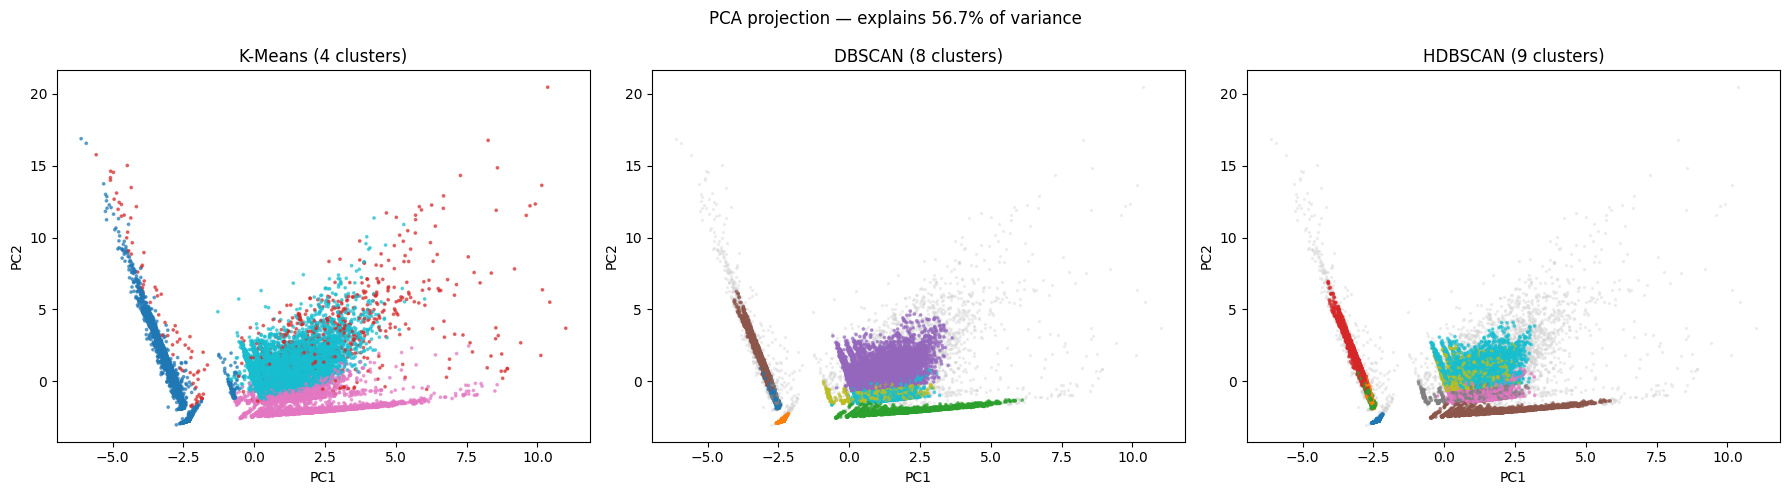

Feature loadings (sorted by PC1):
                            PC1    PC2
tokens_received_count    -0.124  0.475
tokens_sent_count        -0.105  0.485
unique_tokens_received   -0.071  0.475
unique_tokens_sent       -0.067  0.469
unique_senders           -0.036 -0.025
total_value_eth_received  0.059  0.179
total_value_eth_sent      0.151  0.191
contract_call_ratio       0.374  0.054
unique_recipients         0.429  0.107
avg_gas                   0.443  0.001
tx_count                  0.456  0.074
tx_frequency              0.456  0.074


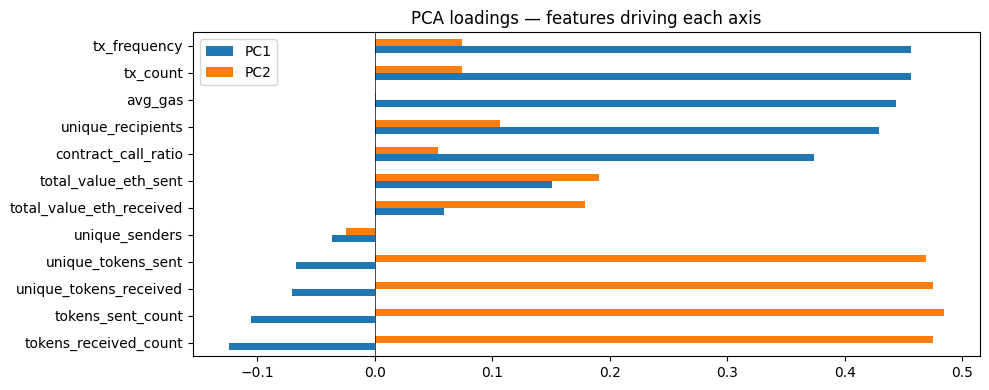

In [107]:
# Cell 8: spot-check a few wallets per cluster — copy these into Etherscan
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, labels) in zip(axes, [("K-Means", km_labels), ("DBSCAN", db_labels), ("HDBSCAN", hdb_labels)]):
    # noise points (-1) plotted in light gray
    noise_mask = labels == -1
    ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=2, alpha=0.3, label="noise")
    ax.scatter(X_2d[~noise_mask, 0], X_2d[~noise_mask, 1], c=labels[~noise_mask], cmap="tab10", s=3, alpha=0.6)
    ax.set_title(f"{name} ({len(set(labels)) - (1 if -1 in labels else 0)} clusters)")
    ax.set_xlabel(f"PC1"); ax.set_ylabel("PC2")

plt.suptitle(f"PCA projection — explains {explained:.1%} of variance")
plt.tight_layout()
plt.savefig("../data/processed/cluster_comparison_pca.png", dpi=100)
plt.show()

# Features Influencing PCA

loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=FEATURE_COLS)
print("Feature loadings (sorted by PC1):")
print(loadings.sort_values("PC1").round(3))

# also plot
fig, ax = plt.subplots(figsize=(10, 4))
loadings.sort_values("PC1").plot(kind="barh", ax=ax)
ax.axvline(0, color="black", lw=0.5)
ax.set_title("PCA loadings — features driving each axis")
plt.tight_layout()
plt.savefig("../data/processed/pca_loadings.png", dpi=100)
plt.show()

# Umap Visualization

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


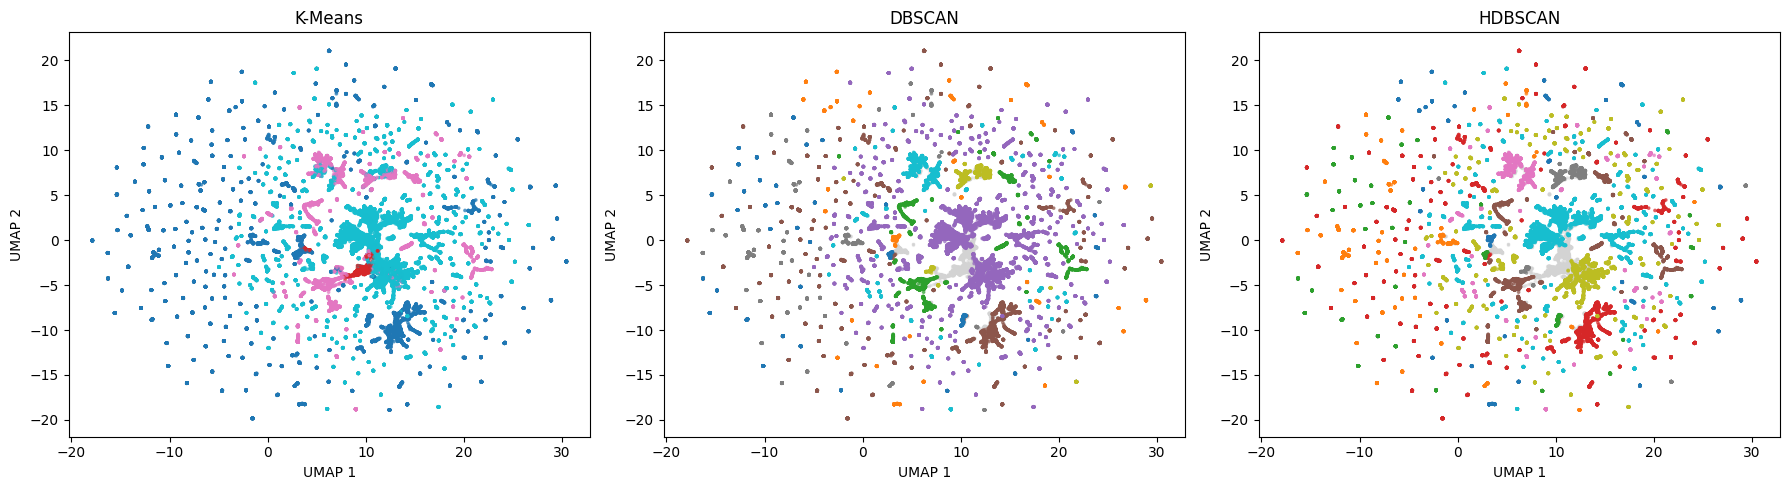

In [106]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, labels) in zip(axes, [("K-Means", km_labels), ("DBSCAN", db_labels), ("HDBSCAN", hdb_labels)]):
    noise_mask = labels == -1
    ax.scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], c="lightgray", s=2, alpha=0.3)
    ax.scatter(X_umap[~noise_mask, 0], X_umap[~noise_mask, 1], c=labels[~noise_mask], cmap="tab10", s=3, alpha=0.6)
    ax.set_title(f"{name}")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.savefig("../data/processed/cluster_comparison_umap.png", dpi=100)
plt.show()

In [ ]:
# Saving for dashboard
results.to_csv("../data/processed/wallet_clusters.csv", index=False)

# save 2D projections for plotting
pd.DataFrame({
    "wallet": results["wallet"],
    "pca1": X_2d[:, 0], "pca2": X_2d[:, 1],
    "umap1": X_umap[:, 0], "umap2": X_umap[:, 1],
    "km_cluster": km_labels,
    "db_cluster": db_labels,
    "hdb_cluster": hdb_labels,
    "archetype": results["archetype"],
}).to_csv("../data/processed/wallet_projections.csv", index=False)

print("Saved wallet_clusters.csv and wallet_projections.csv")

Saved wallet_clusters.csv and wallet_projections.csv
